Import

In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

Reading Files

In [26]:
essays = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/essays.csv')
outcomes = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/outcomes.csv')
projects = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/projects.csv')
donations = pd.read_csv('kdd-cup-2014-predicting-excitement-at-donors-choose/data/donations.csv')

Merging

In [27]:
combined = projects.merge(outcomes,how='inner',on='projectid').merge(essays,how='inner',on='projectid')

In [28]:
combined.isna().sum()

projectid                                              0
teacher_acctid_x                                       0
schoolid                                               0
school_ncesid                                      38848
school_latitude                                        0
school_longitude                                       0
school_city                                            0
school_state                                           0
school_zip                                             4
school_metro                                       75488
school_district                                      922
school_county                                         17
school_charter                                         0
school_magnet                                          0
school_year_round                                      0
school_nlns                                            0
school_kipp                                            0
school_charter_ready_promise   

Preparing the Data

In [29]:
#dropping columns that are not important such as teacher account id
#dropping columns with too many categories such as school city

columns = ['projectid','school_state','school_metro','school_magnet','school_nlns',
           'school_kipp','school_charter','school_charter_ready_promise','teacher_teach_for_america',
           'teacher_ny_teaching_fellow','primary_focus_subject','primary_focus_area',
           'resource_type','poverty_level','grade_level','total_price_excluding_optional_support',
           'total_price_including_optional_support','students_reached','eligible_double_your_impact_match',
           'eligible_almost_home_match','date_posted','fully_funded','short_description','need_statement','essay']

data = combined[columns]

In [30]:
#convert t/f values to binary for relevant categorical data

columns_binary = ['school_magnet','school_nlns',
           'school_kipp','school_charter','school_charter_ready_promise','teacher_teach_for_america',
           'teacher_ny_teaching_fellow','eligible_double_your_impact_match',
           'eligible_almost_home_match','fully_funded']

binary_map = {'f':0,'t':1}

for col in columns_binary:
    data.loc[:,col] = data[col].map(binary_map)

data

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,...,total_price_excluding_optional_support,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay
0,62526d85d2a1818432d03d600969e99c,IL,suburban,0,0,0,0,0,0,0,...,444.36,522.78,7.0,0,0,2013-12-31,1,"If they can't learn the way we teach, we teach...","My students need puzzles, games and visual lea...","If they can't learn the way we teach, we teach..."
1,33d59ac771b80222ad63ef0f4ac47ade,ID,urban,0,0,0,0,0,0,0,...,233.24,274.40,30.0,0,0,2013-12-31,0,"Which is bigger, three liters or three quarts?...",My students need capacity tools and resources ...,"Which is bigger, three liters or three quarts?..."
2,1a3aaeffc56dd2a421e37d8298024c0a,NH,suburban,0,0,0,0,0,0,0,...,285.09,335.40,230.0,0,0,2013-12-31,0,Do you remember classrooms that used just book...,My students need UV sensitive beads and a Vern...,Do you remember classrooms that used just book...
3,33aa19ee4da4c5adf47d0dfb84fab5ef,VA,urban,0,0,0,0,0,0,0,...,232.94,274.05,18.0,0,0,2013-12-31,0,My class was given the beautiful gift of books...,My students need labels and book bins to organ...,My class was given the beautiful gift of books...
4,e31c0ea8b68f404699dfb0d39e9bc99b,IL,urban,1,0,0,0,0,0,0,...,513.41,604.01,70.0,1,0,2013-12-31,1,Thinking back in school science was either rea...,My students need an Interactive whiteboard les...,Thinking back in school science was either rea...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619321,a7236ea96c812895cafc5d700d779147,NY,urban,0,0,0,0,0,0,0,...,231.00,281.71,0.0,0,0,2002-09-17,1,My name is Mary Reide. I am a New York City T...,"The cost of this proposal is [price], includin...",My name is Mary Reide. I am a New York City T...
619322,e02da37beb332eb66c2d2ba989c597ad,NY,urban,0,0,0,0,0,0,0,...,1129.00,1376.83,0.0,0,0,2002-09-17,1,I teach economics to 25 students at Satellite ...,"The cost of this proposal is $1377, including ...",I teach economics to 25 students at Satellite ...
619323,82e536f14eadf2671a70e03416f695a3,NY,urban,1,0,0,0,0,0,0,...,125.00,152.44,0.0,0,0,2002-09-16,1,I just returned from 3 weeks in S. Africa. I w...,"The cost of this proposal is [price], includin...",I just returned from 3 weeks in S. Africa. I ...
619324,e139df754a873a62d93daa56acbf8040,NY,NaN,0,0,0,0,0,0,0,...,125.00,152.44,0.0,0,0,2002-09-13,1,I teach 9th grade Humanities at Vanguard High ...,"The cost of this proposal is [price], includin...",I teach 9th grade Humanities at Vanguard High ...


Normalizing to Address Outlier Issues

In [31]:
data['students_reached'].describe()

count    619182.000000
mean         97.439624
std        2364.069969
min           0.000000
25%          22.000000
50%          30.000000
75%         100.000000
max      999999.000000
Name: students_reached, dtype: float64

<Axes: xlabel='students_reached_scaled', ylabel='Count'>

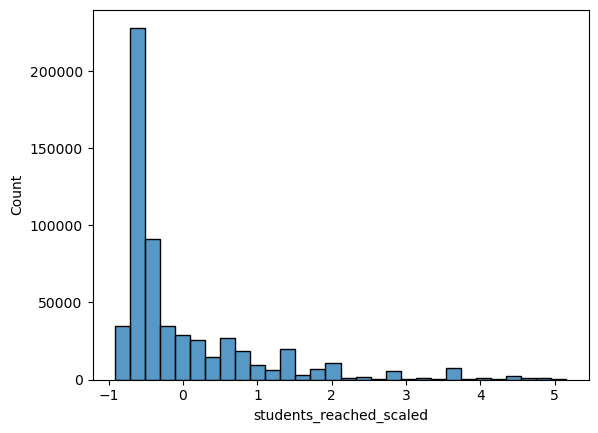

In [32]:
q = data['students_reached'].quantile(0.95)

scaler = StandardScaler()
data = data[data['students_reached'] < q]
data = data[data['students_reached'] > 0]

data['students_reached_scaled'] = scaler.fit_transform(data.loc[:,['students_reached']])

sns.histplot(data['students_reached_scaled'],bins=30, kde=False)


In [33]:
q = data['total_price_excluding_optional_support'].describe()

<Axes: xlabel='total_price_excluding_optional_support_scaled', ylabel='Count'>

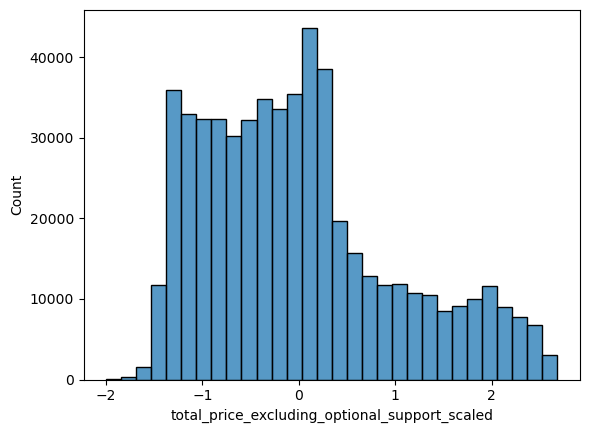

In [34]:
q = data['total_price_excluding_optional_support'].quantile(0.95)

data = data[data['total_price_excluding_optional_support'] < q]
data = data[data['total_price_excluding_optional_support'] > 0]

data['total_price_excluding_optional_support_scaled'] = scaler.fit_transform(data.loc[:,['total_price_excluding_optional_support']])

sns.histplot(data['total_price_excluding_optional_support_scaled'],bins=30, kde=False)

Mapping State to Regions

In [35]:
state_to_region = {
    # Northeast
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    
    # Midwest
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    
    # South
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South',
    'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    
    # West
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West',
    'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

In [36]:
data['school_state_region'] = data['school_state'].map(state_to_region)

In [37]:
data

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,...,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay,students_reached_scaled,total_price_excluding_optional_support_scaled,school_state_region
0,62526d85d2a1818432d03d600969e99c,IL,suburban,0,0,0,0,0,0,0,...,0,0,2013-12-31,1,"If they can't learn the way we teach, we teach...","My students need puzzles, games and visual lea...","If they can't learn the way we teach, we teach...",-0.822545,0.109299,Midwest
1,33d59ac771b80222ad63ef0f4ac47ade,ID,urban,0,0,0,0,0,0,0,...,0,0,2013-12-31,0,"Which is bigger, three liters or three quarts?...",My students need capacity tools and resources ...,"Which is bigger, three liters or three quarts?...",-0.472092,-0.911863,West
2,1a3aaeffc56dd2a421e37d8298024c0a,NH,suburban,0,0,0,0,0,0,0,...,0,0,2013-12-31,0,Do you remember classrooms that used just book...,My students need UV sensitive beads and a Vern...,Do you remember classrooms that used just book...,2.575328,-0.661071,Northeast
3,33aa19ee4da4c5adf47d0dfb84fab5ef,VA,urban,0,0,0,0,0,0,0,...,0,0,2013-12-31,0,My class was given the beautiful gift of books...,My students need labels and book bins to organ...,My class was given the beautiful gift of books...,-0.654937,-0.913315,South
4,e31c0ea8b68f404699dfb0d39e9bc99b,IL,urban,1,0,0,0,0,0,0,...,1,0,2013-12-31,1,Thinking back in school science was either rea...,My students need an Interactive whiteboard les...,Thinking back in school science was either rea...,0.137392,0.443286,Midwest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618803,19385e8ea05843fbdc37b1dd166c7c19,DC,urban,0,1,0,0,0,0,0,...,0,0,2003-01-12,1,I teach sixth grade in an elementary school in...,NaN,I teach sixth grade in an elementary school in...,-0.624463,-0.572508,South
618816,fe896ad6ccd650d896cc534974cf37fc,DC,urban,0,1,0,0,0,0,0,...,0,0,2002-12-19,0,Our school has a supply of many sweatshirts an...,NaN,Our school has a supply of many sweatshirts an...,-0.624463,-0.666827,South
618817,b14e58f6bf4d35c6e6e15800d4575387,DC,urban,0,0,0,0,0,0,0,...,0,0,2002-12-19,0,Seaton E.S. is located in Ward 2 in the northw...,NaN,Seaton E.S. is located in Ward 2 in the northw...,-0.624463,-1.957791,South
618818,118758c17c760f086553d5a064532b03,DC,urban,0,0,0,0,0,0,0,...,0,0,2002-12-19,0,I am the Special Education Resource Teacher at...,NaN,I am the Special Education Resource Teacher at...,-0.624463,0.283378,South


Dropping Null

In [38]:
#sort ascending chronologically

data = data.sort_values(by='date_posted')

#drop missing value

percent_loss = round((data.shape[0] - data.dropna().shape[0])/data.shape[0],4)

print(f'{percent_loss*100}%')

12.479999999999999%


In [39]:
data.dropna(inplace=True)
data

,projectid,school_state,school_metro,school_magnet,school_nlns,school_kipp,school_charter,school_charter_ready_promise,teacher_teach_for_america,teacher_ny_teaching_fellow,...,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,fully_funded,short_description,need_statement,essay,students_reached_scaled,total_price_excluding_optional_support_scaled,school_state_region
618176,e05428ddfb30e295844feb11b9d33553,NY,urban,0,0,0,0,0,0,0,...,0,0,2003-06-19,1,"I am a first grade teacher at PS 7, Abraham Li...","The cost of a Language Center, purchased at ww...","I am a first grade teacher at PS 7, Abraham Li...",-0.624463,0.736352,Northeast
617736,16605cd564a9611768636b5d0925cb9f,NY,urban,0,0,0,0,0,0,1,...,0,0,2003-07-09,1,"I am a third grade teacher at PS 169, a title ...",The cost of 28 book titles about the continent...,"I am a third grade teacher at PS 169, a title ...",-0.243535,-0.790651,Northeast
617455,b3d9d45512362d48ba2b701ac7b87d11,NY,urban,0,0,0,0,0,0,0,...,0,0,2003-08-16,1,I am a second grade teacher in a Title I schoo...,The cost for a supply of prizes such as pencil...,I am a second grade teacher in a Title I schoo...,-0.548277,-0.894257,Northeast
617364,67d25016a34607c3284f05e343bca777,NY,urban,0,0,0,0,0,0,0,...,0,0,2003-09-01,1,Hello. I am a third grade teacher at P.S.169. ...,"The cost of a Rotating Wire Book Rack is $287,...",Hello. I am a third grade teacher at P.S.1...,-0.624463,-0.905189,Northeast
617325,3710a8c738487f7eafc2c903a2f46cb2,NY,urban,0,0,0,0,0,0,0,...,0,0,2003-09-08,1,"I am a music teacher, turned third grade teach...","The cost of creating a library, complete with ...","I am a music teacher, turned third grade teach...",-0.441618,2.399708,Northeast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,f820ef3537f4445b0716244fae36f763,ID,urban,0,0,0,0,0,0,0,...,0,0,2013-12-31,0,Math and reading are two separate subjects in ...,My students need a large range of math stories...,Math and reading are two separate subjects in ...,-0.472092,-0.698412,West
131,95ee208a51831edffa7cc2e0aa3e83cd,AZ,urban,0,0,0,0,0,0,0,...,0,0,2013-12-31,1,Remember the first book you ever loved? How yo...,My students need books to improve their readin...,Remember the first book you ever loved? How yo...,0.564031,-1.061323,West
130,383500f017fea60562ba737b051e1d21,MN,suburban,0,0,0,0,0,0,0,...,0,0,2013-12-31,1,"I will be honest with you, I'm horrible at pre...",My students need funding for a workshop at The...,"I will be honest with you, I'm horrible at pre...",-0.487329,0.559806,Midwest
151,12eaae86b748362dfad4e68b2c5508a2,AZ,rural,0,0,0,0,0,0,0,...,0,0,2013-12-31,0,My class absolutely loves math. It is their fa...,"My students need Math resources, for new Math ...",My class absolutely loves math. It is their fa...,0.899247,-1.131603,West


Export Data as CSV

In [40]:
data.to_csv('data.csv', index=False)

EDA

In [41]:
data[['total_price_excluding_optional_support','students_reached','fully_funded']].groupby('fully_funded').describe()

total_price_excluding_optional_support                          \
                                              count        mean         std   
fully_funded                                                                  
0                                          138067.0  498.091835  207.325950   
1                                          346981.0  392.988082  199.177085   

                                                    students_reached  \
               min      25%    50%      75%     max            count   
fully_funded                                                           
0             17.0  345.245  457.9  648.245  974.99         138067.0   
1              9.0  233.230  363.0  484.000  974.99         346981.0   

                                                                  
                   mean        std  min   25%   50%   75%    max  
fully_funded                                                      
0             60.469207  65.653322  1.0  22.0  30.0  78.0  399.0  
1             59.770336  64.416281  1.0  22.0  30.0  75.0  399.0

<Axes: xlabel='students_reached_scaled', ylabel='Count'>

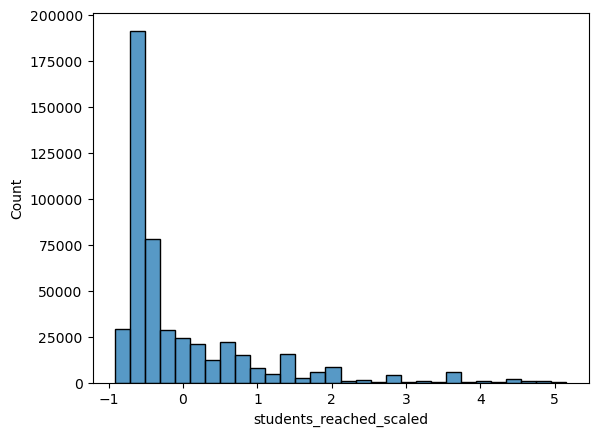

In [42]:
#student reached distribution (same as above)
sns.histplot(data['students_reached_scaled'],bins=30, kde=False)

<Axes: xlabel='total_price_excluding_optional_support_scaled', ylabel='Count'>

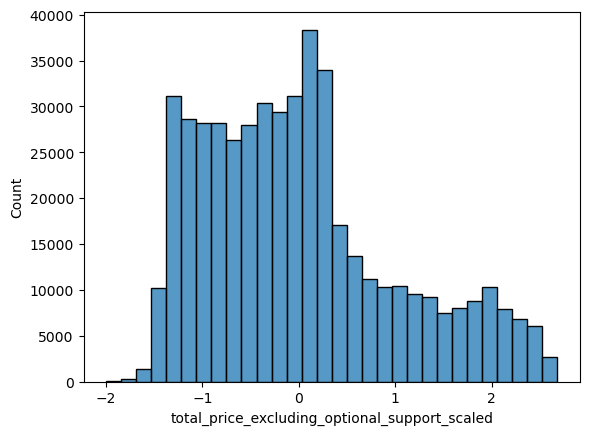

In [43]:
#funds requested (same as above)
sns.histplot(data['total_price_excluding_optional_support_scaled'],bins=30, kde=False)

<Axes: xlabel='resource_type', ylabel='fully_funded'>

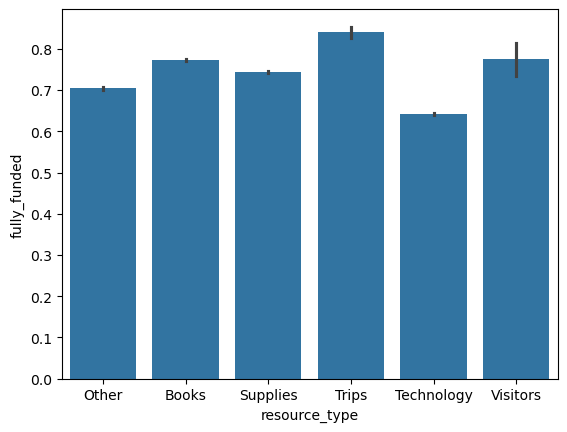

In [44]:
#resource type
sns.barplot(x='resource_type', y='fully_funded', data=data)

<Axes: xlabel='school_state', ylabel='fully_funded'>

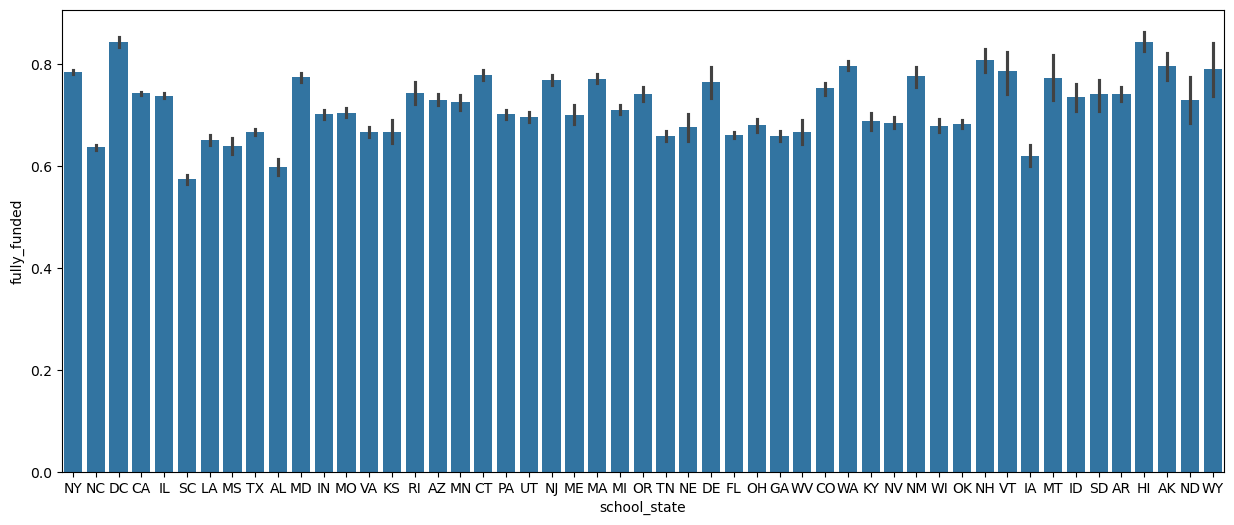

In [45]:
#school state
plt.figure(figsize=(15, 6))
sns.barplot(x='school_state', y='fully_funded', data=data)

<Axes: xlabel='school_state_region', ylabel='fully_funded'>

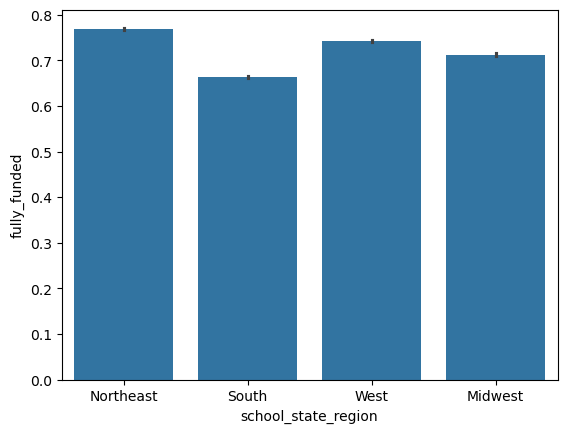

In [46]:
#school state region
sns.barplot(x='school_state_region', y='fully_funded', data=data)

<Axes: xlabel='primary_focus_subject', ylabel='fully_funded'>

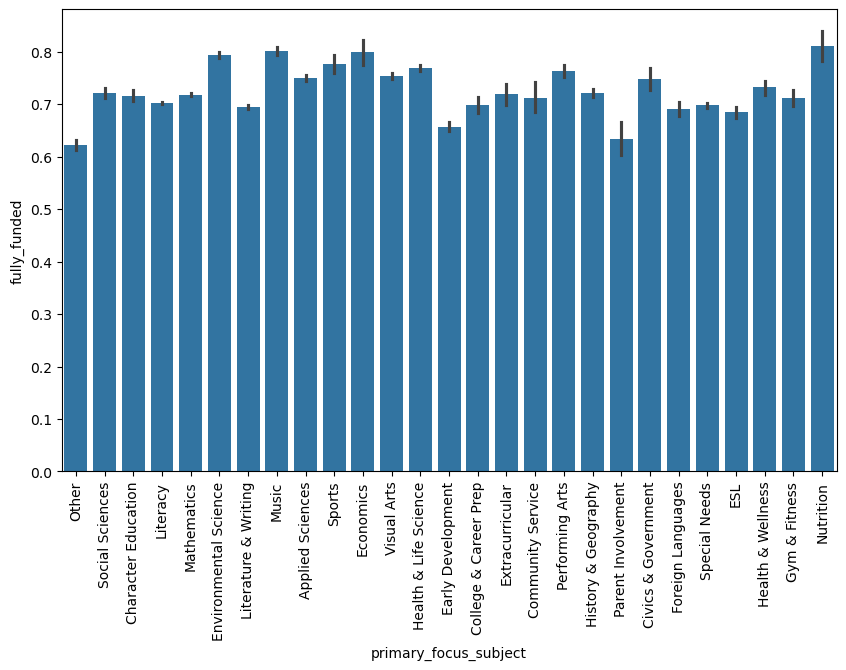

In [47]:
#subject
plt.figure(figsize=(10, 6))
plt.xticks(rotation=90) 
sns.barplot(x='primary_focus_subject', y='fully_funded', data=data)

<Axes: xlabel='primary_focus_area', ylabel='fully_funded'>

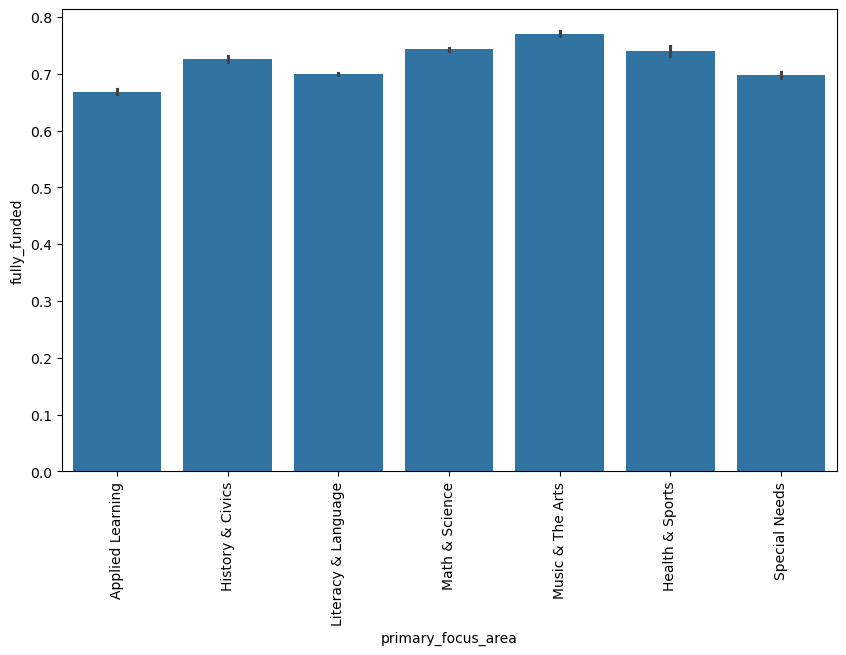

In [48]:
#subject
plt.figure(figsize=(10, 6))
plt.xticks(rotation=90) 
sns.barplot(x='primary_focus_area', y='fully_funded', data=data)

<Axes: xlabel='school_metro', ylabel='fully_funded'>

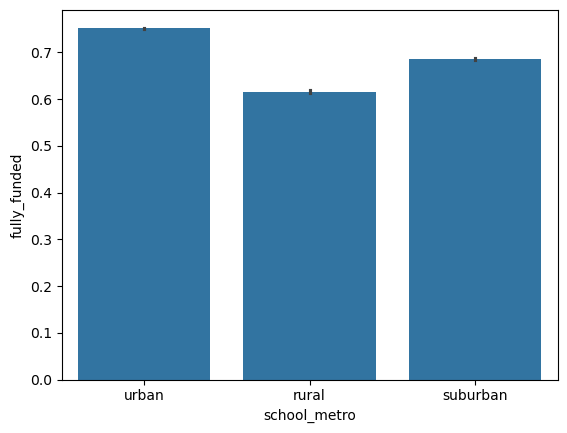

In [49]:
#school metro
sns.barplot(x='school_metro', y='fully_funded', data=data)

<Axes: xlabel='poverty_level', ylabel='fully_funded'>

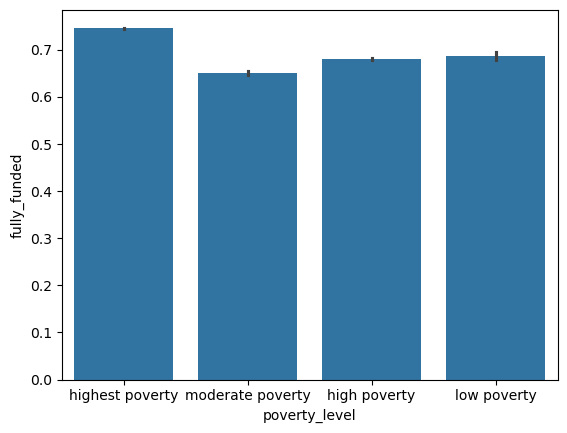

In [50]:
#poverty level
sns.barplot(x='poverty_level', y='fully_funded', data=data)

<Axes: xlabel='resource_type', ylabel='fully_funded'>

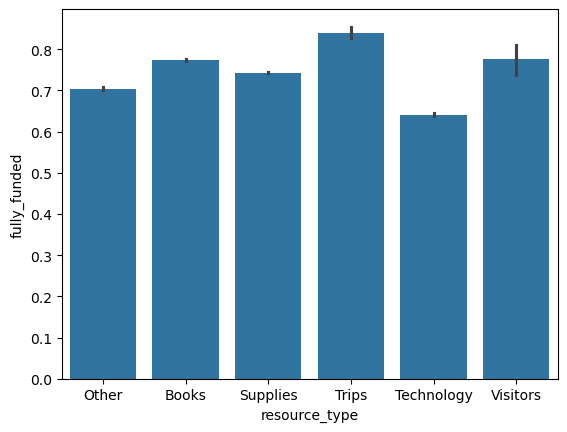

In [51]:
#resource type
sns.barplot(x='resource_type', y='fully_funded', data=data)

<Axes: xlabel='grade_level', ylabel='fully_funded'>

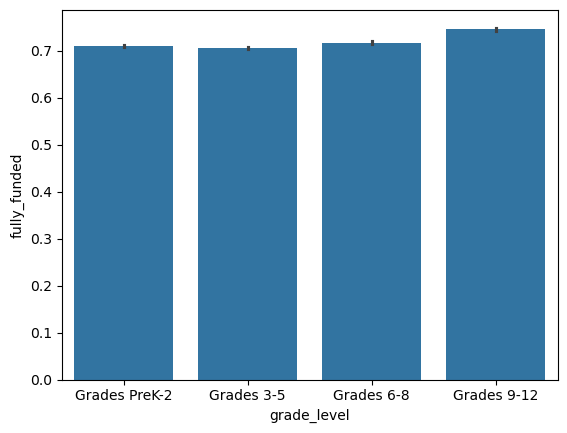

In [52]:
#grade level
sns.barplot(x='grade_level', y='fully_funded', data=data)

<Axes: xlabel='school_charter', ylabel='fully_funded'>

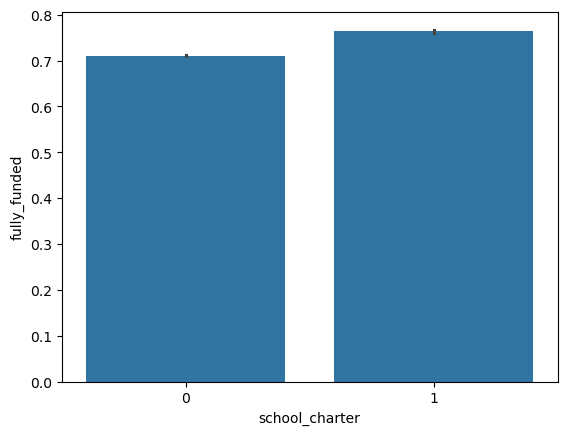

In [61]:
#charter school status
sns.barplot(x='school_charter', y='fully_funded', data=data)

<Axes: xlabel='school_kipp', ylabel='fully_funded'>

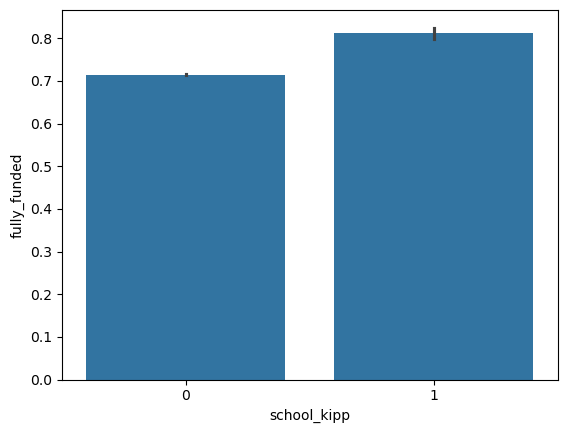

In [54]:
#kipp status
sns.barplot(x='school_kipp', y='fully_funded', data=data)

<Axes: xlabel='school_nlns', ylabel='fully_funded'>

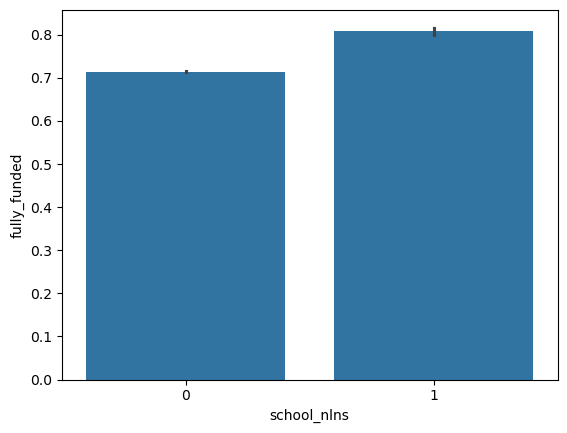

In [55]:
#nlns status
sns.barplot(x='school_nlns', y='fully_funded', data=data)

<Axes: xlabel='school_magnet', ylabel='fully_funded'>

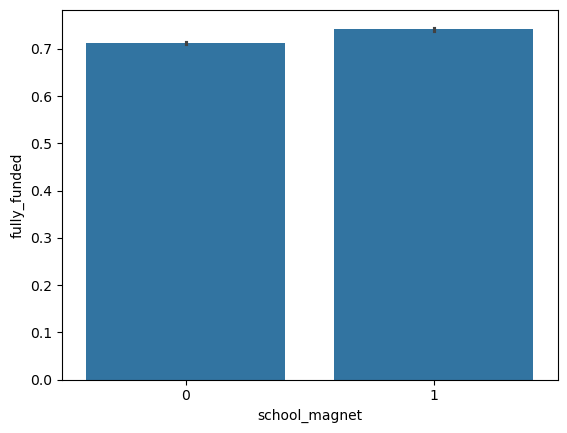

In [56]:
#magnet status
sns.barplot(x='school_magnet', y='fully_funded', data=data)

<Axes: xlabel='eligible_double_your_impact_match', ylabel='fully_funded'>

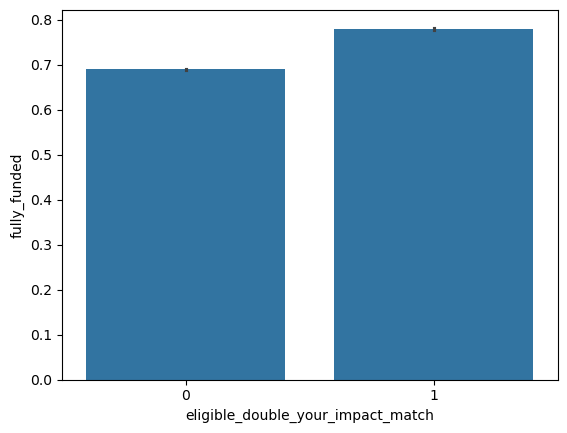

In [57]:
#matching status
sns.barplot(x='eligible_double_your_impact_match', y='fully_funded', data=data)

<Axes: xlabel='eligible_almost_home_match', ylabel='fully_funded'>

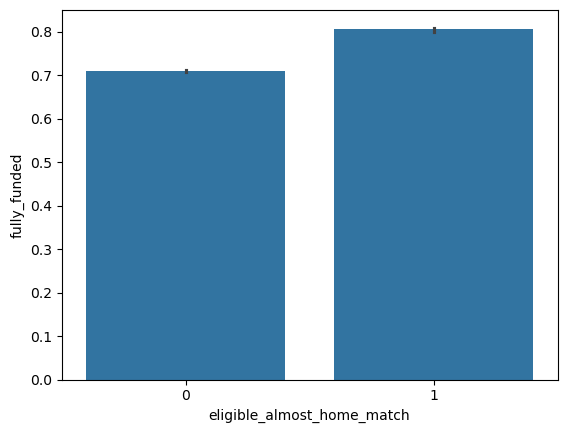

In [58]:
#home match status
sns.barplot(x='eligible_almost_home_match', y='fully_funded', data=data)

<Axes: xlabel='teacher_teach_for_america', ylabel='fully_funded'>

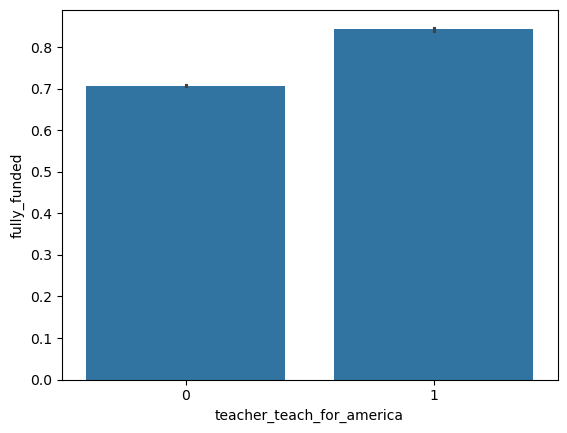

In [59]:
#teach of america status
sns.barplot(x='teacher_teach_for_america', y='fully_funded', data=data)

<Axes: xlabel='teacher_ny_teaching_fellow', ylabel='fully_funded'>

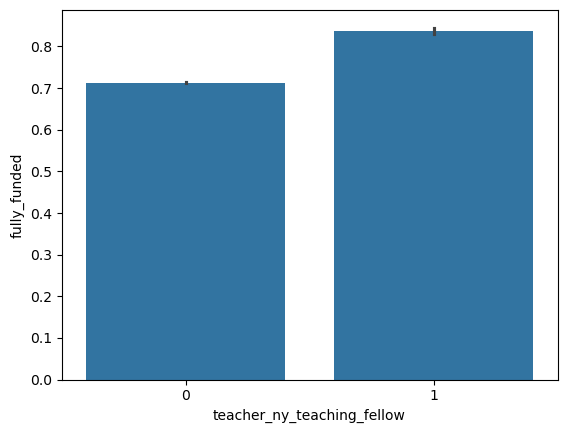

In [60]:
#ny teaching fellow status
sns.barplot(x='teacher_ny_teaching_fellow', y='fully_funded', data=data)